# Импортируем необходимые библиотеки

In [ ]:
!pip install catboost optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.5/242.5 kB 19.8 MB/s eta 0:00:00


In [ ]:
import os
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score

from catboost import CatBoostClassifier, Pool
from xgboost import XGBClassifier
import lightgbm as lgb

import optuna

import warnings
warnings.filterwarnings('ignore')

# Загрузим данные

In [ ]:
!unzip -q mlcourse-dota2-win-prediction.zip -d /content/

In [ ]:
ROOT_DIR = 'mlcourse-dota2-win-prediction'

train_features = pd.read_csv(os.path.join(ROOT_DIR, 'train_features.csv'), index_col='match_id_hash')
train_targets = pd.read_csv(os.path.join(ROOT_DIR, 'train_targets.csv'), index_col='match_id_hash')

In [ ]:
train_features.head(2)

,game_time,game_mode,lobby_type,objectives_len,chat_len,r1_hero_id,r1_kills,r1_deaths,r1_assists,r1_denies,...,d5_stuns,d5_creeps_stacked,d5_camps_stacked,d5_rune_pickups,d5_firstblood_claimed,d5_teamfight_participation,d5_towers_killed,d5_roshans_killed,d5_obs_placed,d5_sen_placed
match_id_hash,,,,,,,,,,,,,,,,,,,,,
a400b8f29dece5f4d266f49f1ae2e98a,155,22,7,1,11,11,0,0,0,0,...,0.0,0,0,0,0,0.0,0,0,0,0
b9c57c450ce74a2af79c9ce96fac144d,658,4,0,3,10,15,7,2,0,7,...,0.0,0,0,0,0,0.0,0,0,0,0


In [ ]:
train_targets.head(2)

,game_time,radiant_win,duration,time_remaining,next_roshan_team
match_id_hash,,,,,
a400b8f29dece5f4d266f49f1ae2e98a,155,False,992,837,NaN
b9c57c450ce74a2af79c9ce96fac144d,658,True,1154,496,NaN


In [ ]:
X = train_features
y = train_targets['radiant_win']

# EDA (5 баллов)

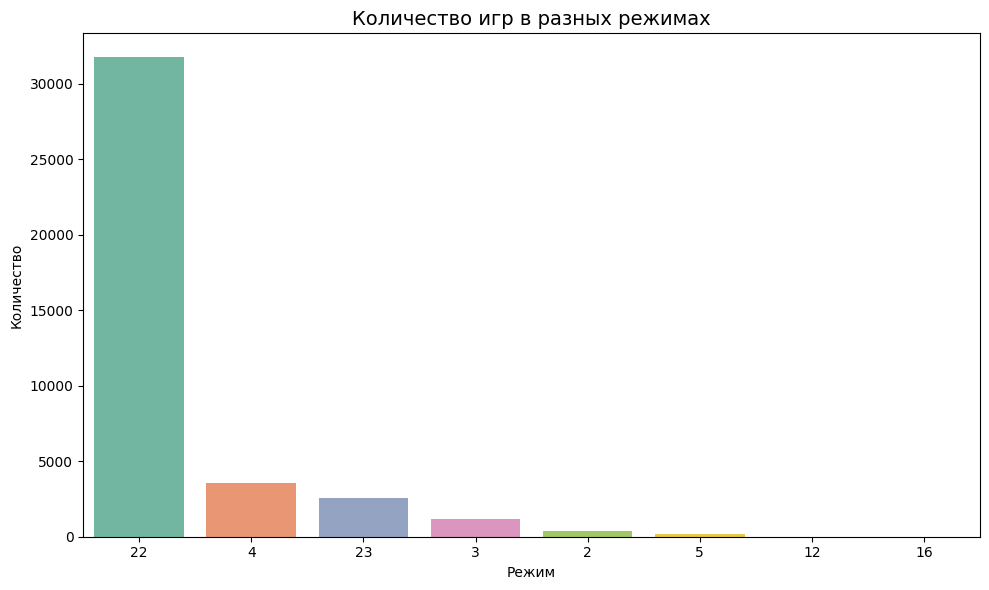

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

custom_palette = sns.color_palette("Set2")

plt.figure(figsize=(10,6))
sns.countplot(
    x='game_mode',
    data=X,
    order=X['game_mode'].value_counts().index,
    palette=custom_palette
)
plt.title('Количество игр в разных режимах', fontsize=14)
plt.xlabel('Режим')
plt.ylabel('Количество')
plt.tight_layout()
plt.show()

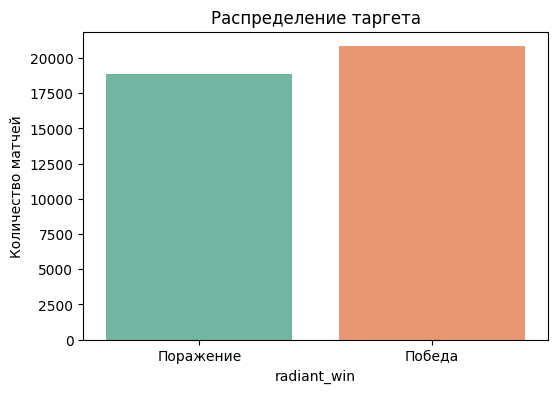

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x=y, palette='Set2')
plt.title('Распределение таргета')
plt.ylabel('Количество матчей')
plt.xticks([0, 1], ['Поражение', 'Победа'])
plt.show()

lobby_type
7    27049
0    12626
Name: count, dtype: int64


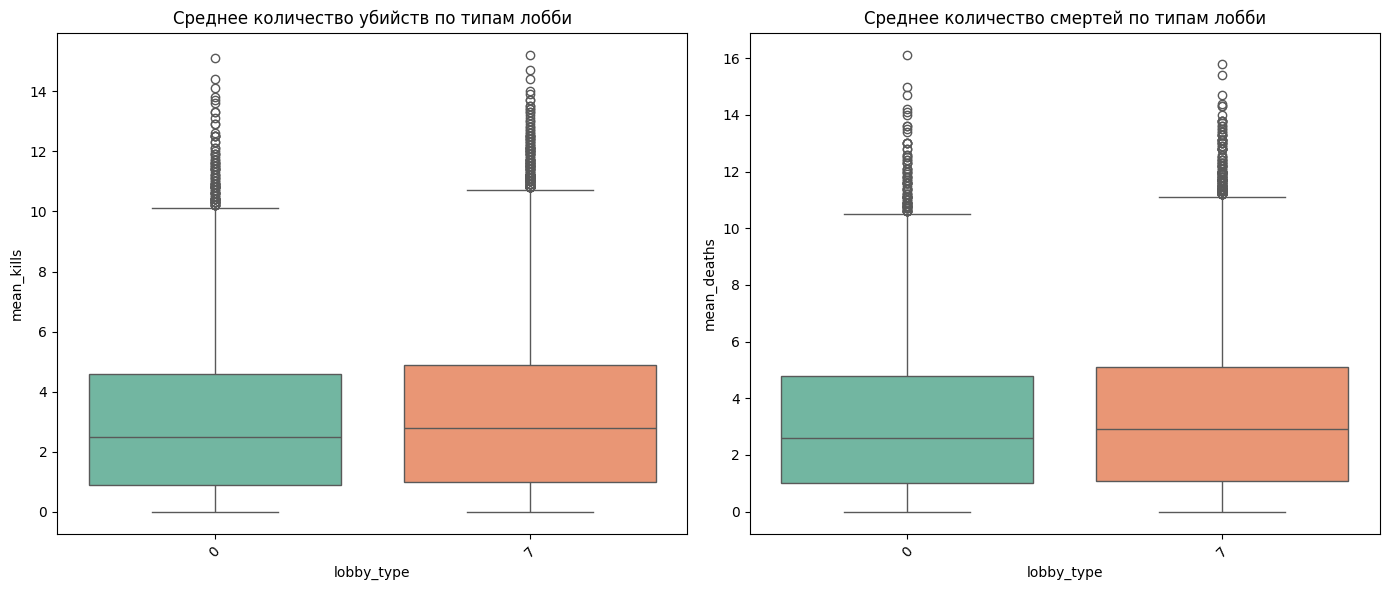

In [ ]:
from scipy.stats import kruskal

custom_palette = sns.color_palette("Set2")

print(X['lobby_type'].value_counts())

kills_cols = [col for col in X.columns if '_kills' in col]
deaths_cols = [col for col in X.columns if '_deaths' in col]

X['mean_kills'] = X[kills_cols].mean(axis=1)
X['mean_deaths'] = X[deaths_cols].mean(axis=1)

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
sns.boxplot(data=X, x='lobby_type', y='mean_kills', palette=custom_palette)
plt.title('Среднее количество убийств по типам лобби')
plt.xticks(rotation=45)

plt.subplot(1,2,2)
sns.boxplot(data=X, x='lobby_type', y='mean_deaths', palette=custom_palette)
plt.title('Среднее количество смертей по типам лобби')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

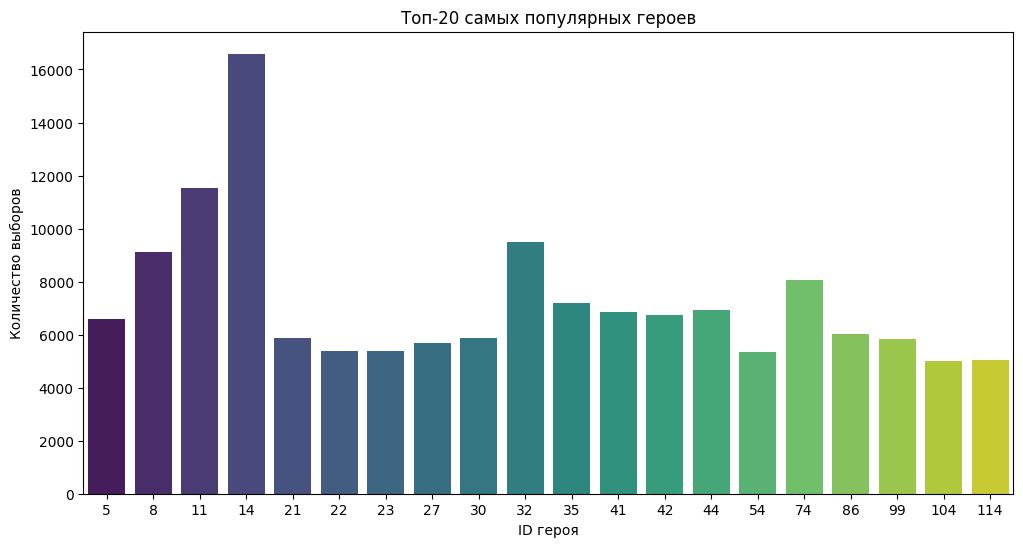

In [ ]:
hero_cols = [col for col in X.columns if col.endswith('_hero_id')]

all_heroes = pd.concat([X[col] for col in hero_cols])

hero_counts = all_heroes.value_counts().reset_index()
hero_counts.columns = ['hero_id', 'count']
top_20 = hero_counts.head(20)

plt.figure(figsize=(12,6))
sns.barplot(data=top_20, x='hero_id', y='count', palette='viridis')
plt.title('Топ-20 самых популярных героев')
plt.xlabel('ID героя')
plt.ylabel('Количество выборов')
plt.show()

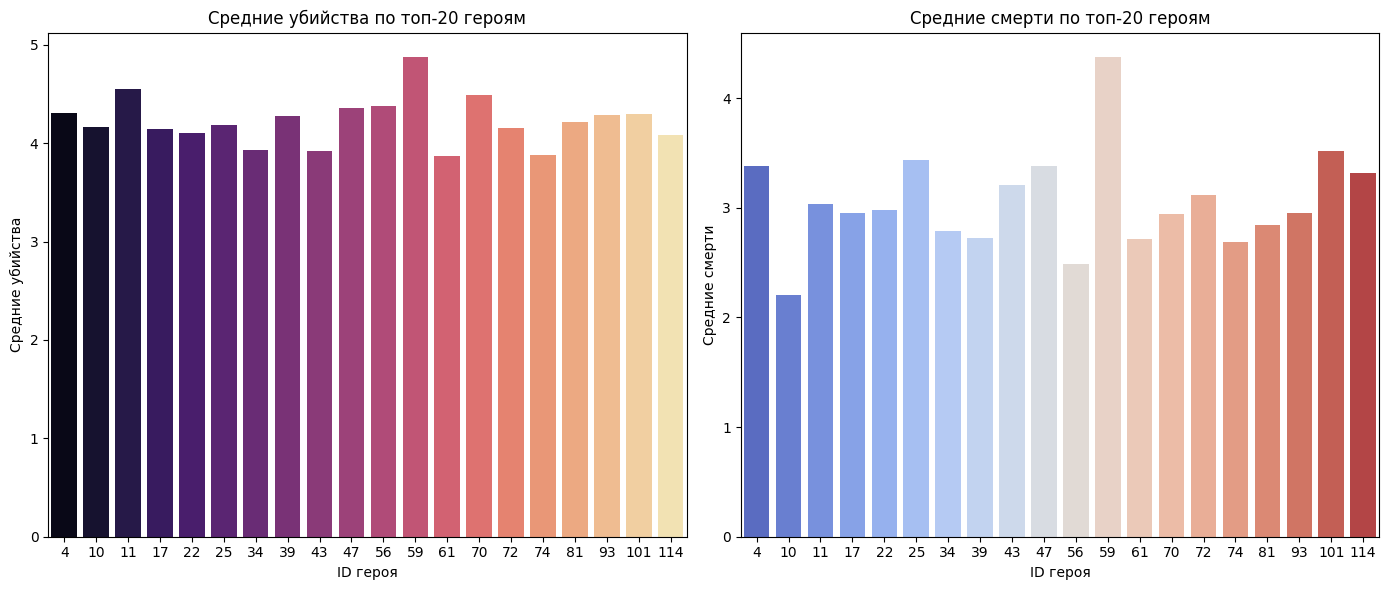

In [ ]:
hero_cols = [col for col in X.columns if col.endswith('_hero_id')]
kills_cols = [col for col in X.columns if col.endswith('_kills')]
deaths_cols = [col for col in X.columns if col.endswith('_deaths')]
data = []

for hero_col, kill_col, death_col in zip(hero_cols, kills_cols, deaths_cols):
    temp_df = pd.DataFrame({
        'hero_id': X[hero_col],
        'kills': X[kill_col],
        'deaths': X[death_col]
    })
    data.append(temp_df)

all_players_df = pd.concat(data, ignore_index=True)
hero_stats = all_players_df.groupby('hero_id').agg({'kills': 'mean', 'deaths': 'mean'}).reset_index()
hero_stats = hero_stats.sort_values(by='kills', ascending=False)

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
sns.barplot(data=hero_stats.head(20), x='hero_id', y='kills', palette='magma')
plt.title('Средние убийства по топ-20 героям')
plt.xlabel('ID героя')
plt.ylabel('Средние убийства')

plt.subplot(1,2,2)
sns.barplot(data=hero_stats.head(20), x='hero_id', y='deaths', palette='coolwarm')
plt.title('Средние смерти по топ-20 героям')
plt.xlabel('ID героя')
plt.ylabel('Средние смерти')


plt.tight_layout()
plt.show()

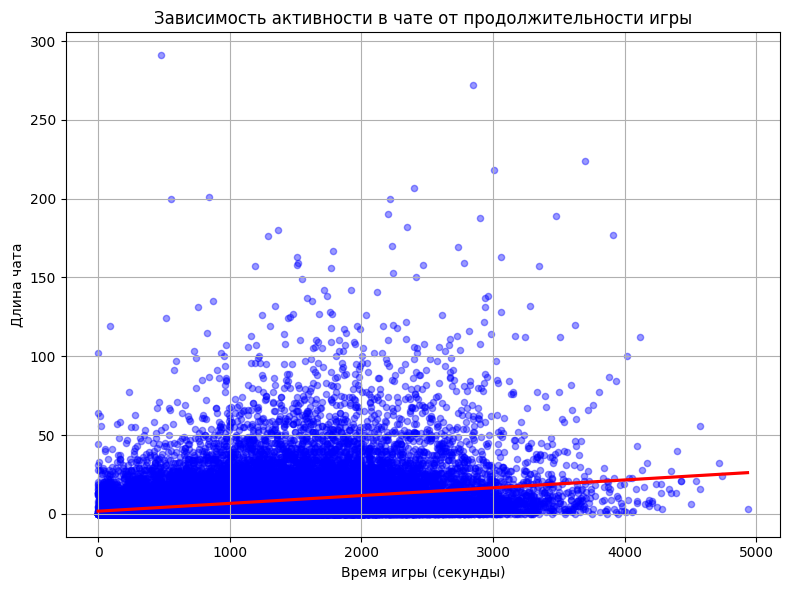

In [ ]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=X,
    x='game_time',
    y='chat_len',
    scatter_kws={'alpha': 0.4, 's': 20},
    line_kws={'color': 'red'},
    color='blue'
)

plt.title('Зависимость активности в чате от продолжительности игры')
plt.xlabel('Время игры (секунды)')
plt.ylabel('Длина чата')
plt.grid(True)
plt.tight_layout()
plt.show()

# Обучим CatBoost на чистых данных и посмотрим на метрики

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=69)
oof_cat = np.zeros(len(X))

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    model = CatBoostClassifier(
        early_stopping_rounds=100,
        random_state=69,
        verbose=0,
        thread_count=4
    )
    model.fit(X_train, y_train, eval_set=(X_valid, y_valid))

    y_pred = model.predict_proba(X_valid)[:, 1]

    fold_roc_auc = roc_auc_score(y_valid, y_pred)
    fold_acc = accuracy_score(y_valid, y_pred > 0.5)
    print(f'FOLD {fold}, Validation ROC-AUC score: {fold_roc_auc:.4f}, Accuracy score: {fold_acc:.4f}')

    oof_cat[valid_idx] = y_pred

oof_roc_auc = roc_auc_score(y, oof_cat)
oof_accuracy = accuracy_score(y, oof_cat > 0.5)
print(f'\nOverall CAT OOF ROC-AUC: {oof_roc_auc:.4f}, OOF Accuracy: {oof_accuracy:.4f}')

FOLD 0, Validation ROC-AUC score: 0.8172, Accuracy score: 0.7298
FOLD 1, Validation ROC-AUC score: 0.8061, Accuracy score: 0.7195
FOLD 2, Validation ROC-AUC score: 0.8019, Accuracy score: 0.7115
FOLD 3, Validation ROC-AUC score: 0.8070, Accuracy score: 0.7207
FOLD 4, Validation ROC-AUC score: 0.8062, Accuracy score: 0.7226

Overall CAT OOF ROC-AUC: 0.8077, OOF Accuracy: 0.7208


# Генерация фичей (5 баллов)

Генерация фичей является одной из важнейших частей построения пайплайна машинного обучения. В данной части вам предлагается придумать и сгенерировать полезные фичи для модели. Важно: они должны повысить метрику. В качестве примера сгенерированы статистические фичи. Вы можете не использовать их, если не считаете их нужными.

In [ ]:
def fe(data):
    stats_cols = [
        'kills', 'deaths', 'assists', 'denies', 'gold', 'lh', 'xp',
        'health', 'max_health', 'max_mana', 'level', 'x', 'y',
        'stuns', 'creeps_stacked', 'camps_stacked', 'rune_pickups',
        'firstblood_claimed', 'teamfight_participation', 'towers_killed',
        'roshans_killed', 'obs_placed', 'sen_placed'
    ]

    eps = 1e-8

    for c in stats_cols:
        r_cols = [f'r{i}_{c}' for i in range(1, 6)]
        d_cols = [f'd{i}_{c}' for i in range(1, 6)]

        data[f'r_total_{c}'] = data[r_cols].sum(axis=1)
        data[f'd_total_{c}'] = data[d_cols].sum(axis=1)
        data[f'{c}_ratio'] = data[f'r_total_{c}'] / (data[f'd_total_{c}'] + eps)

        data[f'r_mean_{c}'] = data[r_cols].mean(axis=1)
        data[f'd_mean_{c}'] = data[d_cols].mean(axis=1)

        data[f'r_std_{c}'] = data[r_cols].std(axis=1)
        data[f'd_std_{c}'] = data[d_cols].std(axis=1)

    data['level_diff'] = data['r_mean_level'] - data['d_mean_level']

    data['r_total_networth'] = data['r_total_gold'] + data['r_total_xp']
    data['d_total_networth'] = data['d_total_gold'] + data['d_total_xp']
    data['networth_ratio'] = data['r_total_networth'] / (data['d_total_networth'] + eps)

    data['r_x_mean'] = data[[f'r{i}_x' for i in range(1, 6)]].mean(axis=1)
    data['r_y_mean'] = data[[f'r{i}_y' for i in range(1, 6)]].mean(axis=1)
    data['d_x_mean'] = data[[f'd{i}_x' for i in range(1, 6)]].mean(axis=1)
    data['d_y_mean'] = data[[f'd{i}_y' for i in range(1, 6)]].mean(axis=1)
    data['map_position_diff'] = (
        (data['r_x_mean'] - data['d_x_mean'])**2 +
        (data['r_y_mean'] - data['d_y_mean'])**2
    ) ** 0.5

    data['firstblood_radiant'] = (
        data[[f'r{i}_firstblood_claimed' for i in range(1, 6)]].sum(axis=1) > 0
    ).astype(int)
    data['firstblood_dire'] = (
        data[[f'd{i}_firstblood_claimed' for i in range(1, 6)]].sum(axis=1) > 0
    ).astype(int)

    data['obs_diff'] = data['r_total_obs_placed'] - data['d_total_obs_placed']
    data['sen_diff'] = data['r_total_sen_placed'] - data['d_total_sen_placed']

    data['teamfight_participation_diff'] = (
        data['r_total_teamfight_participation'] - data['d_total_teamfight_participation']
    )

    return data

# Теперь обучим CatBoost на данных с новыми фичами и посмотрим на метрики

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=69)
oof_cat = np.zeros(len(X))

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    # чтобы в тест не утекли глобальные статистики трейна, сначала сплитим, потом генерируем фичи
    X_train = fe(X_train)
    X_valid = fe(X_valid)

    model = CatBoostClassifier(
        early_stopping_rounds=100,
        random_state=69,
        verbose=0,
        thread_count=4
    )
    model.fit(X_train, y_train, eval_set=(X_valid, y_valid))

    y_pred = model.predict_proba(X_valid)[:, 1]

    fold_roc_auc = roc_auc_score(y_valid, y_pred)
    fold_acc = accuracy_score(y_valid, y_pred > 0.5)
    print(f'FOLD {fold}, Validation ROC-AUC score: {fold_roc_auc:.4f}, Accuracy score: {fold_acc:.4f}')

    oof_cat[valid_idx] = y_pred

oof_roc_auc = roc_auc_score(y, oof_cat)
oof_accuracy = accuracy_score(y, oof_cat > 0.5)
print(f'\nOverall OOF ROC-AUC: {oof_roc_auc:.4f}, OOF Accuracy: {oof_accuracy:.4f}')

FOLD 0, Validation ROC-AUC score: 0.8376, Accuracy score: 0.7469
FOLD 1, Validation ROC-AUC score: 0.8187, Accuracy score: 0.7290
FOLD 2, Validation ROC-AUC score: 0.8193, Accuracy score: 0.7293
FOLD 3, Validation ROC-AUC score: 0.8200, Accuracy score: 0.7301
FOLD 4, Validation ROC-AUC score: 0.8256, Accuracy score: 0.7376

Overall OOF ROC-AUC: 0.8241, OOF Accuracy: 0.7346


# Обработка категориальных фичей средствами CatBoost

Попробуем подать категориальные фичи в модель через cat_features.

In [ ]:
# выделим очевидные категориальные фичи - вы можете попробовать выделить больше / сгенерировать новые или же вовсе отказаться от этой идеи
cats = ['game_mode', 'lobby_type']

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=69)
oof_cat = np.zeros(len(X))

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    # чтобы в тест не утекли глобальные статистики трейна, сначала сплитим, потом генерируем фичи
    X_train = fe(X_train)
    X_valid = fe(X_valid)

    model = CatBoostClassifier(
        cat_features=cats,
        early_stopping_rounds=100,
        random_state=69,
        verbose=0,
        thread_count=4
    )
    model.fit(X_train, y_train, eval_set=(X_valid, y_valid))

    y_pred = model.predict_proba(X_valid)[:, 1]

    fold_roc_auc = roc_auc_score(y_valid, y_pred)
    fold_acc = accuracy_score(y_valid, y_pred > 0.5)
    print(f'FOLD {fold}, Validation ROC-AUC score: {fold_roc_auc:.4f}, Accuracy score: {fold_acc:.4f}')

    oof_cat[valid_idx] = y_pred

oof_roc_auc = roc_auc_score(y, oof_cat)
oof_accuracy = accuracy_score(y, oof_cat > 0.5)
print(f'\nOverall CAT w/ FE OOF ROC-AUC: {oof_roc_auc:.4f}, OOF Accuracy: {oof_accuracy:.4f}')

FOLD 0, Validation ROC-AUC score: 0.8355, Accuracy score: 0.7449
FOLD 1, Validation ROC-AUC score: 0.8178, Accuracy score: 0.7270
FOLD 2, Validation ROC-AUC score: 0.8204, Accuracy score: 0.7333
FOLD 3, Validation ROC-AUC score: 0.8189, Accuracy score: 0.7249
FOLD 4, Validation ROC-AUC score: 0.8271, Accuracy score: 0.7365

Overall CAT w/ FE OOF ROC-AUC: 0.8238, OOF Accuracy: 0.7333


# Отбор фичей (5 баллов)

Возможно, на этапе генерации фичей вы решили прибегнуть к автоматической генерации (если нет, то советую обратить внимание на библиотеку OpenFE), или же просто генерировали все подряд. Также, возможно, исходные данные содержали бесполезные и шумные фичи.

Вам предлагается исследовать это и оставить только те фичи, которые вы считаете важными.

Идеи для отбора фичей:
- по feature importance
- по permutation importance
- по shap values
- recursive feature elimination
- sequential feature selection

Также обратите внимание на гайд от catboost: https://github.com/catboost/catboost/blob/master/catboost/tutorials/feature_selection/select_features_tutorial.ipynb

In [ ]:
# Подготовка данных
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=69)
X_train = fe(X_train)
X_test = fe(X_test)

# Обучение модели
model = CatBoostClassifier(
    cat_features=cats,
    random_state=69,
    verbose=0,
    iterations=1000,
    early_stopping_rounds=100
)

train_pool = Pool(X_train, y_train, cat_features=cats)
test_pool = Pool(X_test, y_test, cat_features=cats)

summary = model.select_features(
    train_pool,
    eval_set=test_pool,
    features_for_select=list(range(X_train.shape[1])),
    num_features_to_select=350,
    algorithm='RecursiveByShapValues',
    steps=5,
    shap_calc_type='Regular',
    train_final_model=False,
    plot=False
)



selected_features = summary['selected_features']

Learning rate set to 0.073263
Step #1 out of 5
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.4997348579
bestIteration = 518

Shrink model to first 519 iterations.
Feature #413 eliminated
Feature #29 eliminated
Feature #137 eliminated
Feature #421 eliminated
Feature #206 eliminated
Feature #361 eliminated
Feature #312 eliminated
Feature #13 eliminated
Feature #205 eliminated
Feature #415 eliminated
Feature #213 eliminated
Feature #166 eliminated
Feature #19 eliminated
Feature #226 eliminated
Feature #115 eliminated
Step #2 out of 5
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.5010071542
bestIteration = 263

Shrink model to first 264 iterations.
Feature #114 eliminated
Feature #18 eliminated
Feature #249 eliminated
Feature #81 eliminated
Feature #234 eliminated
Feature #53 eliminated
Feature #330 eliminated
Feature #60 eliminated
Feature #331 eliminated
Feature #41 eliminated
Feature #111 eliminated
Feature #230 eliminated
Feature #233 elimi

# Обучим модель на отобранных и фичах и посмотрим на метрики

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=69)
oof_cat = np.zeros(len(X))

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    # чтобы в тест не утекли глобальные статистики трейна, сначала сплитим, потом генерируем фичи
    X_train = fe(X_train).iloc[:, selected_features]
    X_valid = fe(X_valid).iloc[:, selected_features]

    model = CatBoostClassifier(
        cat_features=cats,
        early_stopping_rounds=100,
        random_state=69,
        verbose=0,
        thread_count=4
    )
    model.fit(X_train, y_train, eval_set=(X_valid, y_valid))

    y_pred = model.predict_proba(X_valid)[:, 1]

    fold_roc_auc = roc_auc_score(y_valid, y_pred)
    fold_acc = accuracy_score(y_valid, y_pred > 0.5)
    print(f'FOLD {fold}, Validation ROC-AUC score: {fold_roc_auc:.4f}, Accuracy score: {fold_acc:.4f}')

    oof_cat[valid_idx] = y_pred

oof_roc_auc = roc_auc_score(y, oof_cat)
oof_accuracy = accuracy_score(y, oof_cat > 0.5)
print(f'\nOverall CAT w/ FE&FS OOF ROC-AUC: {oof_roc_auc:.4f}, OOF Accuracy: {oof_accuracy:.4f}')

FOLD 0, Validation ROC-AUC score: 0.8379, Accuracy score: 0.7487
FOLD 1, Validation ROC-AUC score: 0.8184, Accuracy score: 0.7283
FOLD 2, Validation ROC-AUC score: 0.8195, Accuracy score: 0.7299
FOLD 3, Validation ROC-AUC score: 0.8221, Accuracy score: 0.7338
FOLD 4, Validation ROC-AUC score: 0.8256, Accuracy score: 0.7356

Overall CAT w/ FE&FS OOF ROC-AUC: 0.8246, OOF Accuracy: 0.7353


# Блендинг: добавим XGBoost и LightGBM

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=69)
oof_lgb = np.zeros(len(X))

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    # чтобы в тест не утекли глобальные статистики трейна, сначала сплитим, потом генерируем фичи
    X_train = fe(X_train).iloc[:, selected_features]
    X_valid = fe(X_valid).iloc[:, selected_features]

    # lgbm требует указания категориальных фичей как 'category'
    for col in cats:
        X_train[col] = X_train[col].astype('category')
        X_valid[col] = X_valid[col].astype('category')

    model = lgb.LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=69,
        n_jobs=4,
        metric='auc',
        early_stopping_round=100,
        verbosity=-1
    )
    model.fit(
        X_train, y_train,
        eval_set=[(X_valid, y_valid)],
        categorical_feature=cats
    )

    y_pred = model.predict_proba(X_valid)[:, 1]

    fold_roc_auc = roc_auc_score(y_valid, y_pred)
    fold_acc = accuracy_score(y_valid, y_pred > 0.5)
    print(f'FOLD {fold}, Validation ROC-AUC score: {fold_roc_auc:.4f}, Accuracy score: {fold_acc:.4f}')

    oof_lgb[valid_idx] = y_pred

oof_roc_auc = roc_auc_score(y, oof_lgb)
oof_accuracy = accuracy_score(y, oof_lgb > 0.5)
print(f'\nOverall LGB w/ FE&FS OOF ROC-AUC: {oof_roc_auc:.4f}, OOF Accuracy: {oof_accuracy:.4f}')

FOLD 0, Validation ROC-AUC score: 0.8390, Accuracy score: 0.7480
FOLD 1, Validation ROC-AUC score: 0.8181, Accuracy score: 0.7299
FOLD 2, Validation ROC-AUC score: 0.8212, Accuracy score: 0.7311
FOLD 3, Validation ROC-AUC score: 0.8219, Accuracy score: 0.7323
FOLD 4, Validation ROC-AUC score: 0.8268, Accuracy score: 0.7369

Overall LGB w/ FE&FS OOF ROC-AUC: 0.8253, OOF Accuracy: 0.7356


In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=69)
oof_xgb = np.zeros(len(X))

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    # чтобы в тест не утекли глобальные статистики трейна, сначала сплитим, потом генерируем фичи
    X_train = fe(X_train).iloc[:, selected_features]
    X_valid = fe(X_valid).iloc[:, selected_features]

    # xgb требует указания категориальных фичей как 'category'
    for col in cats:
        X_train[col] = X_train[col].astype('category')
        X_valid[col] = X_valid[col].astype('category')

    cat_columns = [X_train.columns.get_loc(col) for col in cats]

    model = XGBClassifier(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=69,
        n_jobs=4,
        eval_metric='auc',
        early_stopping_rounds=100,
        use_label_encoder=False,
        enable_categorical=True,
        tree_method='hist'
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_valid, y_valid)],
        verbose=False
    )

    y_pred = model.predict_proba(X_valid)[:, 1]

    fold_roc_auc = roc_auc_score(y_valid, y_pred)
    fold_acc = accuracy_score(y_valid, y_pred > 0.5)
    print(f'FOLD {fold}, Validation ROC-AUC score: {fold_roc_auc:.4f}, Accuracy score: {fold_acc:.4f}')

    oof_xgb[valid_idx] = y_pred

oof_roc_auc = roc_auc_score(y, oof_xgb)
oof_accuracy = accuracy_score(y, oof_xgb > 0.5)
print(f'\nOverall XGB w/ FE&FS OOF ROC-AUC: {oof_roc_auc:.4f}, OOF Accuracy: {oof_accuracy:.4f}')

FOLD 0, Validation ROC-AUC score: 0.8370, Accuracy score: 0.7482
FOLD 1, Validation ROC-AUC score: 0.8173, Accuracy score: 0.7239
FOLD 2, Validation ROC-AUC score: 0.8195, Accuracy score: 0.7284
FOLD 3, Validation ROC-AUC score: 0.8199, Accuracy score: 0.7309
FOLD 4, Validation ROC-AUC score: 0.8277, Accuracy score: 0.7404

Overall XGB w/ FE&FS OOF ROC-AUC: 0.8240, OOF Accuracy: 0.7344


In [ ]:
# сблендим предсказания и посмотрим на метрики

oof_blend = (oof_cat + oof_lgb + oof_xgb) / 3

oof_roc_auc = roc_auc_score(y, oof_blend)
oof_accuracy = accuracy_score(y, oof_blend > 0.5)
print(f'\nOverall BLEND w/ FE&FS OOF ROC-AUC: {oof_roc_auc:.4f}, OOF Accuracy: {oof_accuracy:.4f}')


Overall BLEND w/ FE&FS OOF ROC-AUC: 0.8265, OOF Accuracy: 0.7371


# Подбор гиперпараметров (15 баллов)

Для изучения того, какие гиперпараметры доступны у модели для выбора можно использовать '? ModelName'
Определитесь с тем, какие гиперпараметры вы хотите оптимизировать и укажите их в objective. Выполните поиск гиперпараметров с Optuna

In [ ]:
# ? lgb.LGBMClassifier

In [ ]:
# ? XGBClassifier

In [ ]:
def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 500, 2000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10, log=True),
        'random_strength': trial.suggest_float('random_strength', 1e-3, 10, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'border_count': trial.suggest_categorical('border_count', [32, 64, 128, 254]),
        'grow_policy': trial.suggest_categorical('grow_policy', ['SymmetricTree', 'Depthwise', 'Lossguide']),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 100),
        'loss_function': 'Logloss',
        'eval_metric': 'AUC',
        'task_type': 'CPU',
        'random_state': 69,
        'verbose': 0,
    }

    if 'cats' in globals():
        params['cat_features'] = cats

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=69)
    oof_cat = np.zeros(len(X))

    for train_idx, valid_idx in skf.split(X, y):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        X_train = fe(X_train).iloc[:, selected_features]
        X_valid = fe(X_valid).iloc[:, selected_features]

        model = CatBoostClassifier(**params)
        model.fit(
            X_train, y_train,
            eval_set=(X_valid, y_valid),
            early_stopping_rounds=100,
            verbose=0
        )

        y_pred = model.predict_proba(X_valid)[:, 1]
        oof_cat[valid_idx] = y_pred

    oof_roc_auc = roc_auc_score(y, oof_cat)

    return oof_roc_auc

In [ ]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, timeout=3600)

cat_params = study.best_params
cat_params

[I 2025-06-06 12:44:58,324] A new study created in memory with name: no-name-6abeb0c3-91a8-4384-be82-6476714fb05f
[I 2025-06-06 12:55:50,932] Trial 0 finished with value: 0.8254125595453273 and parameters: {'iterations': 1206, 'learning_rate': 0.014632097915913213, 'depth': 6, 'l2_leaf_reg': 0.13785640804677085, 'random_strength': 0.05469203527209208, 'bagging_temperature': 0.29155593067989594, 'border_count': 128, 'grow_policy': 'SymmetricTree', 'min_data_in_leaf': 39}. Best is trial 0 with value: 0.8254125595453273.
[I 2025-06-06 13:02:13,425] Trial 1 finished with value: 0.825039668777989 and parameters: {'iterations': 1476, 'learning_rate': 0.04161667837502673, 'depth': 5, 'l2_leaf_reg': 0.667240679053822, 'random_strength': 0.16079020505599254, 'bagging_temperature': 0.27062864944499065, 'border_count': 254, 'grow_policy': 'Depthwise', 'min_data_in_leaf': 3}. Best is trial 0 with value: 0.8254125595453273.
[I 2025-06-06 13:05:47,624] Trial 2 finished with value: 0.8241331583764437

{'iterations': 1206,
 'learning_rate': 0.014632097915913213,
 'depth': 6,
 'l2_leaf_reg': 0.13785640804677085,
 'random_strength': 0.05469203527209208,
 'bagging_temperature': 0.29155593067989594,
 'border_count': 128,
 'grow_policy': 'SymmetricTree',
 'min_data_in_leaf': 39}

In [ ]:
def objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': 'gbdt',
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'num_leaves': trial.suggest_int('num_leaves', 15, 255),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'random_state': 69,
        'n_jobs': 4,
        'verbosity': -1,
        'early_stopping_rounds': 100
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=69)
    oof_lgb = np.zeros(len(X))

    for train_idx, valid_idx in skf.split(X, y):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        X_train = fe(X_train).iloc[:, selected_features]
        X_valid = fe(X_valid).iloc[:, selected_features]

        for col in cats:
            X_train[col] = X_train[col].astype('category')
            X_valid[col] = X_valid[col].astype('category')

        model = lgb.LGBMClassifier(**params)
        model.fit(
            X_train, y_train,
            eval_set=[(X_valid, y_valid)],
            categorical_feature=cats,
        )

        y_pred = model.predict_proba(X_valid)[:, 1]
        oof_lgb[valid_idx] = y_pred

    oof_roc_auc = roc_auc_score(y, oof_lgb)

    return oof_roc_auc

In [ ]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, timeout=3600)

lgb_params = study.best_params
lgb_params

[I 2025-06-06 13:55:19,017] A new study created in memory with name: no-name-20a1fc16-0cb0-4052-b101-de7831454dcd
[I 2025-06-06 13:57:20,842] Trial 0 finished with value: 0.8190371573582378 and parameters: {'n_estimators': 773, 'max_depth': 11, 'num_leaves': 123, 'min_child_samples': 73, 'subsample': 0.7765890353521674}. Best is trial 0 with value: 0.8190371573582378.
[I 2025-06-06 13:58:59,928] Trial 1 finished with value: 0.8210042416229255 and parameters: {'n_estimators': 1443, 'max_depth': 7, 'num_leaves': 96, 'min_child_samples': 14, 'subsample': 0.7366304016439362}. Best is trial 1 with value: 0.8210042416229255.
[I 2025-06-06 14:00:43,496] Trial 2 finished with value: 0.8219884569191689 and parameters: {'n_estimators': 1757, 'max_depth': 8, 'num_leaves': 193, 'min_child_samples': 80, 'subsample': 0.7839803361087557}. Best is trial 2 with value: 0.8219884569191689.
[I 2025-06-06 14:02:02,325] Trial 3 finished with value: 0.8242798405990683 and parameters: {'n_estimators': 1753, '

{'n_estimators': 1065,
 'max_depth': 3,
 'num_leaves': 167,
 'min_child_samples': 24,
 'subsample': 0.8755875856559721}

In [ ]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'eval_metric': 'auc',
        'early_stopping_rounds': 100,
        'use_label_encoder': False,
        'enable_categorical': True,
        'tree_method': 'hist',
        'random_state': 69,
        'n_jobs': 4
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=69)
    oof_xgb = np.zeros(len(X))

    for train_idx, valid_idx in skf.split(X, y):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]


        X_train = fe(X_train).iloc[:, selected_features]
        X_valid = fe(X_valid).iloc[:, selected_features]

        for col in cats:
            X_train[col] = X_train[col].astype('category')
            X_valid[col] = X_valid[col].astype('category')

        model = XGBClassifier(**params)
        model.fit(
            X_train, y_train,
            eval_set=[(X_valid, y_valid)],
            verbose=False
        )

        y_pred = model.predict_proba(X_valid)[:, 1]
        oof_xgb[valid_idx] = y_pred

    oof_roc_auc = roc_auc_score(y, oof_xgb)

    return oof_roc_auc

In [67]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, timeout=3600)

xgb_params = study.best_params

[I 2025-06-06 15:59:01,151] A new study created in memory with name: no-name-b0415761-cf1e-426b-a227-19c0514d9b33
[I 2025-06-06 16:16:18,707] Trial 0 finished with value: 0.8226185816356903 and parameters: {'n_estimators': 409, 'learning_rate': 0.011532711770647632, 'max_depth': 12, 'subsample': 0.8555744399443568, 'colsample_bytree': 0.7614991389053765, 'min_child_weight': 3}. Best is trial 0 with value: 0.8226185816356903.
[I 2025-06-06 16:44:27,474] Trial 1 finished with value: 0.8245957054043616 and parameters: {'n_estimators': 979, 'learning_rate': 0.010006671358887949, 'max_depth': 10, 'subsample': 0.9248629973534539, 'colsample_bytree': 0.9468050908203204, 'min_child_weight': 2}. Best is trial 1 with value: 0.8245957054043616.
[I 2025-06-06 16:46:15,787] Trial 2 finished with value: 0.8154500306119532 and parameters: {'n_estimators': 305, 'learning_rate': 0.23524868746554542, 'max_depth': 8, 'subsample': 0.8844201767663054, 'colsample_bytree': 0.8075304831916333, 'min_child_weig

# Обучим модели с новыми гиперпараметрами

In [68]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=69)
oof_cat = np.zeros(len(X))

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    # чтобы в тест не утекли глобальные статистики трейна, сначала сплитим, потом генерируем фичи
    X_train = fe(X_train).iloc[:, selected_features]
    X_valid = fe(X_valid).iloc[:, selected_features]

    model = CatBoostClassifier(
        ** ,
        early_stopping_rounds=100,
        random_state=69,
        verbose=0,
        thread_count=4
    )
    model.fit(X_train, y_train, eval_set=(X_valid, y_valid))

    y_pred = model.predict_proba(X_valid)[:, 1]

    fold_roc_auc = roc_auc_score(y_valid, y_pred)
    fold_acc = accuracy_score(y_valid, y_pred > 0.5)
    print(f'FOLD {fold}, Validation ROC-AUC score: {fold_roc_auc:.4f}, Accuracy score: {fold_acc:.4f}')

    oof_cat[valid_idx] = y_pred

oof_roc_auc = roc_auc_score(y, oof_cat)
oof_accuracy = accuracy_score(y, oof_cat > 0.5)
print(f'\nOverall Tuned CAT w/ FE&FS OOF ROC-AUC: {oof_roc_auc:.4f}, OOF Accuracy: {oof_accuracy:.4f}')

FOLD 0, Validation ROC-AUC score: 0.8388, Accuracy score: 0.7480
FOLD 1, Validation ROC-AUC score: 0.8193, Accuracy score: 0.7302
FOLD 2, Validation ROC-AUC score: 0.8210, Accuracy score: 0.7282
FOLD 3, Validation ROC-AUC score: 0.8216, Accuracy score: 0.7321
FOLD 4, Validation ROC-AUC score: 0.8265, Accuracy score: 0.7371

Overall Tuned CAT w/ FE&FS OOF ROC-AUC: 0.8253, OOF Accuracy: 0.7351


In [70]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=69)
oof_lgb = np.zeros(len(X))

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    # чтобы в тест не утекли глобальные статистики трейна, сначала сплитим, потом генерируем фичи
    X_train = fe(X_train).iloc[:, selected_features]
    X_valid = fe(X_valid).iloc[:, selected_features]

    # lgbm требует указания категориальных фичей как 'category'
    for col in cats:
        X_train[col] = X_train[col].astype('category')
        X_valid[col] = X_valid[col].astype('category')

    final_params = {
        **lgb_params,
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': 'gbdt',
        'random_state': 69,
        'n_jobs': 4,
        'verbosity': -1,
        'early_stopping_round': 100
    }

    model = lgb.LGBMClassifier(**final_params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_valid, y_valid)],
        categorical_feature=cats
    )

    y_pred = model.predict_proba(X_valid)[:, 1]

    fold_roc_auc = roc_auc_score(y_valid, y_pred)
    fold_acc = accuracy_score(y_valid, y_pred > 0.5)
    print(f'FOLD {fold}, Validation ROC-AUC score: {fold_roc_auc:.4f}, Accuracy score: {fold_acc:.4f}')

    oof_lgb[valid_idx] = y_pred

oof_roc_auc = roc_auc_score(y, oof_lgb)
oof_accuracy = accuracy_score(y, oof_lgb > 0.5)
print(f'\nOverall Tuned LGB w/ FE&FS OOF ROC-AUC: {oof_roc_auc:.4f}, OOF Accuracy: {oof_accuracy:.4f}')

FOLD 0, Validation ROC-AUC score: 0.8393, Accuracy score: 0.7536
FOLD 1, Validation ROC-AUC score: 0.8192, Accuracy score: 0.7304
FOLD 2, Validation ROC-AUC score: 0.8214, Accuracy score: 0.7330
FOLD 3, Validation ROC-AUC score: 0.8221, Accuracy score: 0.7333
FOLD 4, Validation ROC-AUC score: 0.8257, Accuracy score: 0.7389

Overall Tuned LGB w/ FE&FS OOF ROC-AUC: 0.8253, OOF Accuracy: 0.7378


In [71]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=69)
oof_xgb = np.zeros(len(X))

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    # чтобы в тест не утекли глобальные статистики трейна, сначала сплитим, потом генерируем фичи
    X_train = fe(X_train).iloc[:, selected_features]
    X_valid = fe(X_valid).iloc[:, selected_features]

    # xgb требует указания категориальных фичей как 'category'
    for col in cats:
        X_train[col] = X_train[col].astype('category')
        X_valid[col] = X_valid[col].astype('category')

    cat_columns = [X_train.columns.get_loc(col) for col in cats]

    final_params = {
        **xgb_params,
        'eval_metric': 'auc',
        'early_stopping_rounds': 100,
        'use_label_encoder': False,
        'enable_categorical': True,
        'tree_method': 'hist',
        'random_state': 69,
        'n_jobs': 4
    }

    model = XGBClassifier(**final_params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_valid, y_valid)],
        verbose=False
    )

    y_pred = model.predict_proba(X_valid)[:, 1]

    fold_roc_auc = roc_auc_score(y_valid, y_pred)
    fold_acc = accuracy_score(y_valid, y_pred > 0.5)
    print(f'FOLD {fold}, Validation ROC-AUC score: {fold_roc_auc:.4f}, Accuracy score: {fold_acc:.4f}')

    oof_xgb[valid_idx] = y_pred

oof_roc_auc = roc_auc_score(y, oof_xgb)
oof_accuracy = accuracy_score(y, oof_xgb > 0.5)
print(f'\nOverall Tuned XGB w/ FE&FS OOF ROC-AUC: {oof_roc_auc:.4f}, OOF Accuracy: {oof_accuracy:.4f}')

FOLD 0, Validation ROC-AUC score: 0.8377, Accuracy score: 0.7454
FOLD 1, Validation ROC-AUC score: 0.8172, Accuracy score: 0.7265
FOLD 2, Validation ROC-AUC score: 0.8202, Accuracy score: 0.7288
FOLD 3, Validation ROC-AUC score: 0.8215, Accuracy score: 0.7328
FOLD 4, Validation ROC-AUC score: 0.8269, Accuracy score: 0.7381

Overall Tuned XGB w/ FE&FS OOF ROC-AUC: 0.8246, OOF Accuracy: 0.7343


In [72]:
# сблендим предсказания и посмотрим на метрики

oof_blend = (oof_cat + oof_lgb + oof_xgb) / 3

oof_roc_auc = roc_auc_score(y, oof_blend)
oof_accuracy = accuracy_score(y, oof_blend > 0.5)
print(f'\nOverall Tuned BLEND w/ FE&FS OOF ROC-AUC: {oof_roc_auc:.4f}, OOF Accuracy: {oof_accuracy:.4f}')


Overall Tuned BLEND w/ FE&FS OOF ROC-AUC: 0.8268, OOF Accuracy: 0.7382


# Итоговая важность фичей

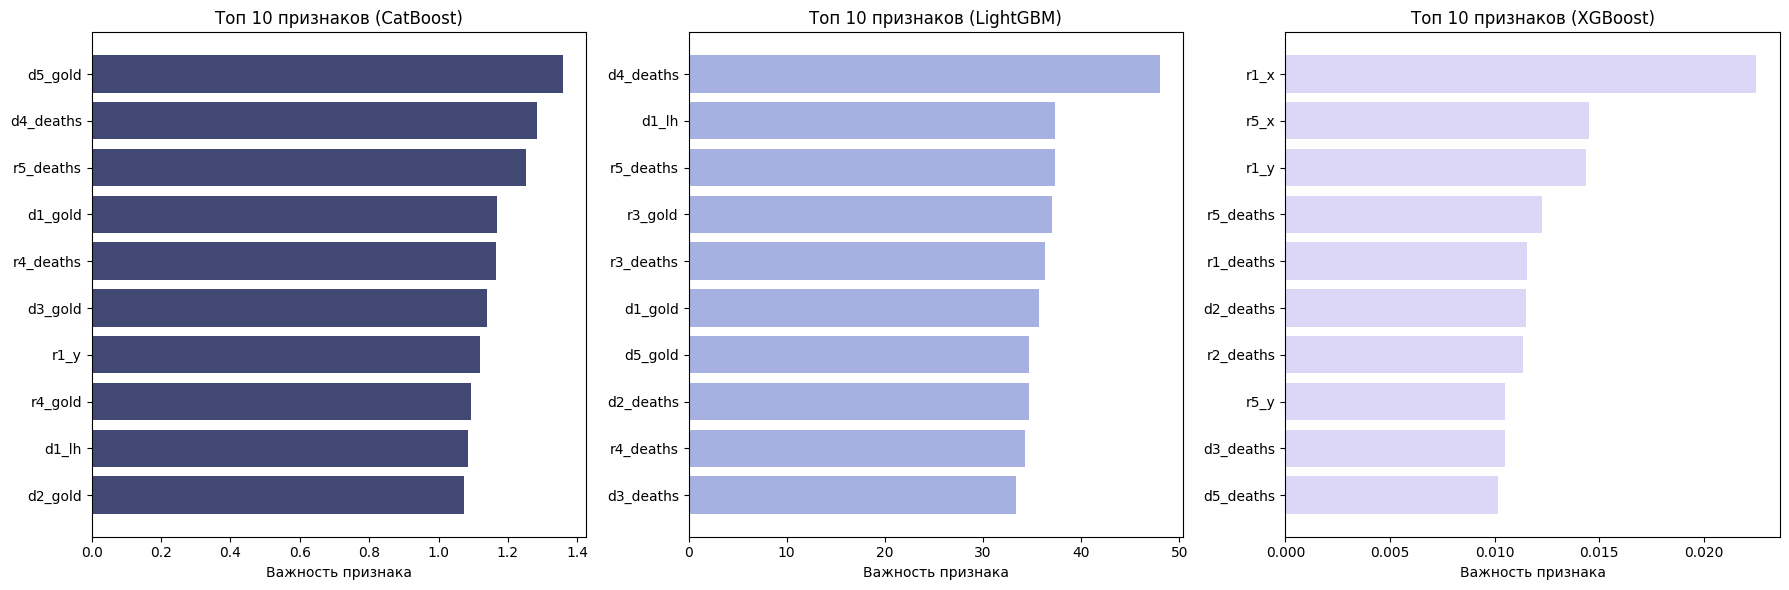

In [77]:
from sklearn.model_selection import StratifiedKFold
from catboost import CatBoostClassifier
import lightgbm as lgb
from xgboost import XGBClassifier

def visualize_feature_rankings(X, y, top_features=15, random_seed=42):

    models = {
        'CatBoost': CatBoostClassifier(verbose=0, random_seed=random_seed),
        'LightGBM': lgb.LGBMClassifier(random_state=random_seed),
        'XGBoost': XGBClassifier(random_state=random_seed)
    }

    importances = {name: [] for name in models}
    feature_names = X.columns

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=random_seed)

    for train_idx, _ in cv.split(X, y):
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]

        for name, model in models.items():
            fitted_model = model.fit(X_train, y_train)

            if name == 'CatBoost':
                imp = fitted_model.get_feature_importance()
            elif name == 'LightGBM':
                imp = fitted_model.feature_importances_
            else:
                imp = fitted_model.feature_importances_

            importances[name].append(imp)

    avg_importances = {
        name: np.mean(imps, axis=0)
        for name, imps in importances.items()
    }

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    colors = ['#424874', '#a6b1e1', '#dcd6f7']

    for ax, (name, imp), color in zip(axes, avg_importances.items(), colors):
        sorted_idx = np.argsort(imp)[-top_features:]
        sorted_imp = imp[sorted_idx]
        sorted_names = feature_names[sorted_idx]

        ax.barh(range(top_features), sorted_imp, color=color)
        ax.set_yticks(range(top_features))
        ax.set_yticklabels(sorted_names)
        ax.set_title(f'Топ {top_features} признаков ({name})')
        ax.set_xlabel('Важность признака')

    plt.tight_layout()
    plt.show()

    return avg_importances, feature_names

feature_importances, feature_names = visualize_feature_rankings(
    X,
    y,
    top_features=10,
    random_seed=69
)